In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [247]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [248]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [249]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_diff.txt', sep='\\s+')
df1

,time,v(vip),v(vop),v(von)
0,1.900000e-09,0.657404,0.633458,0.566520
1,3.900000e-09,0.715503,0.692752,0.507180
2,5.900000e-09,0.768873,0.748260,0.451636
3,7.900000e-09,0.815329,0.797706,0.402171
4,9.900000e-09,0.852970,0.839066,0.360813
...,...,...,...,...
535,6.390000e-08,0.675263,0.897192,0.302868
536,6.590000e-08,0.495742,0.301043,0.898688
537,6.790000e-08,0.732177,0.897137,0.302291
538,6.990000e-08,0.441253,0.306607,0.892553


In [250]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [251]:
vip = np.reshape(df1['v(vip)'].values, [runs, len(df1)//runs])
vop = np.reshape(df1['v(vop)'].values, [runs, len(df1)//runs])
von = np.reshape(df1['v(von)'].values, [runs, len(df1)//runs])
vod = vop - von

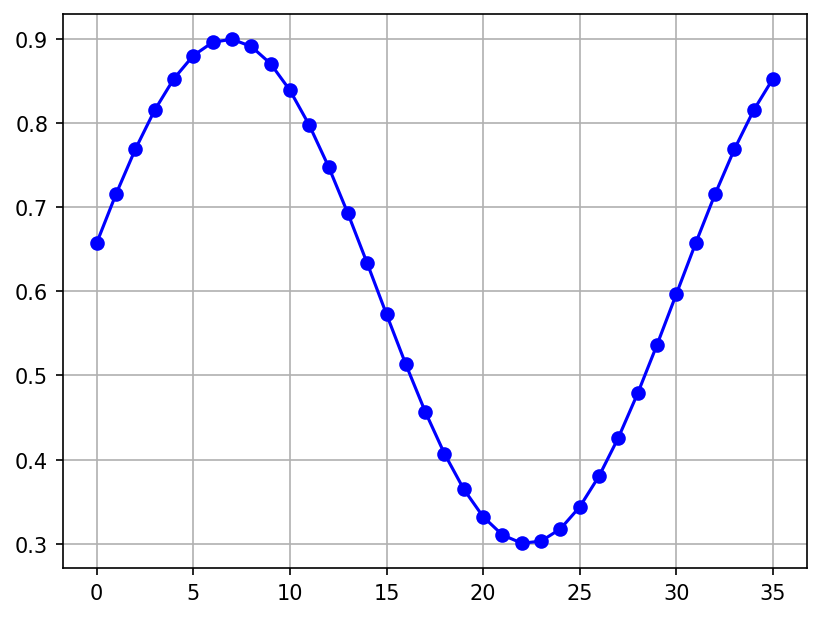

In [252]:
plt.plot(vip[0, :], "b-o")
plt.grid()
plt.show()

In [253]:
hd3_vip = compute_spectra(bins, vip, ndft)[1]
hd3_vop = compute_spectra(bins, vop, ndft)[1]
hd3_vod = compute_spectra(bins, vod, ndft)[1]

5.519245128789092e-09
-5.4008312602504604e-08
-9.971945463102098e-08
-2.784516436906392e-08
2.5510937426054005e-07
1.128647132251976e-08
-2.5745224679269195e-06
-1.423731744807406e-07
-5.661133400548672e-07
-3.9786083457975186e-07
-1.3838860152350566e-07
3.5279953742019197e-07
1.5819588247496368e-06
-6.643042408835433e-06
1.201351509177315e-06
-1.5939473796646902e-06
-1.1141522204538328e-06
-4.1876936727613e-06
1.2811989652447985e-06
4.0225446667985145e-08
-1.813300715353718e-05
-1.2108854647280205e-06
-1.395878051698448e-06
-3.4750894645931294e-07
-4.099987321318821e-06
-1.204670139810904e-06
-4.337910021363002e-06
-2.3994032215356063e-07
-1.3227905956079335e-06
9.275712154564398e-06
-6.429799168961041e-06
-3.34095848618909e-06
-1.4276860155776458e-05
1.1140738062113086e-05
-1.4194029961634044e-07
2.1224610256271052e-05
1.3411235239879306e-06
4.196109363396938e-06
-3.953715391350906e-06
-1.445253852934797e-05
-3.881963019007292e-06
-1.6695716774495052e-05
-7.415622371451685e-06
3.0337

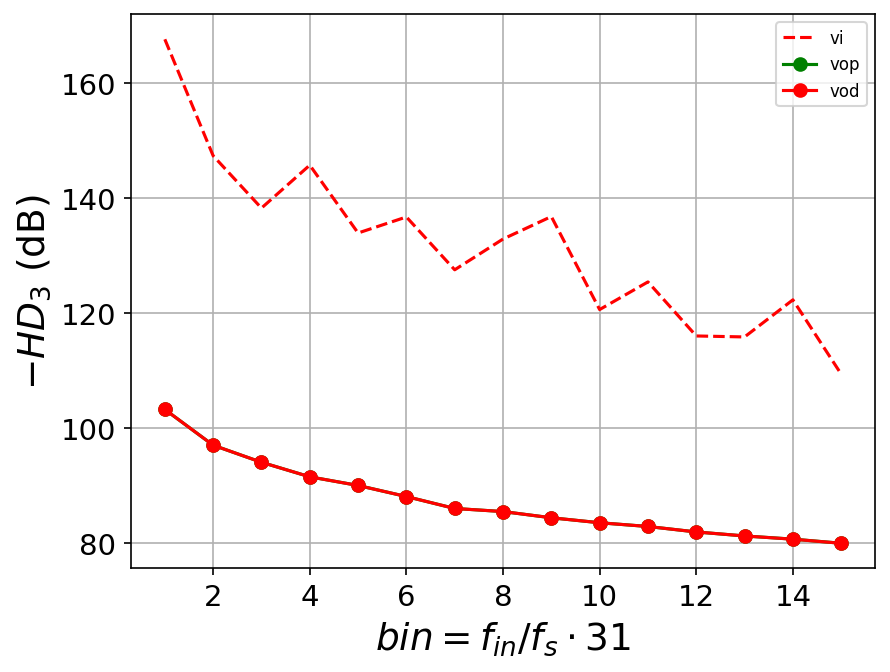

In [254]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_vip, "r--", label='vi')
plt.plot(bins, hd3_vop, "g-o", label='vop')
plt.plot(bins, hd3_vod, "r-o", label='vod')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(50, 140)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-6.429799168961041e-06
-3.34095848618909e-06
-1.4276860155776458e-05
1.1140738062113086e-05
-1.4194029961634044e-07
2.1224610256271052e-05
1.3411235239879306e-06
4.196109363396938e-06
-3.953715391350906e-06
-1.445253852934797e-05
-3.881963019007292e-06
-1.6695716774495052e-05
-7.415622371451685e-06
3.033777826329217e-06
-9.91917011453736e-06


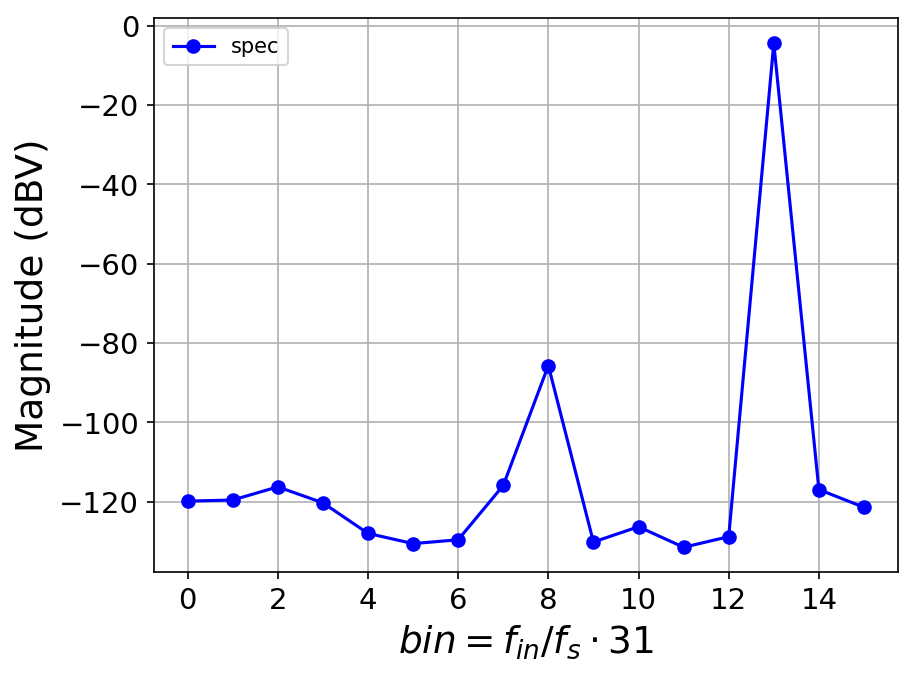

In [255]:
spec_dbv_out = compute_spectra(bins, vod, ndft)[2]

plt.plot(spec_dbv_out[12, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
